# Notebook Native Agent in Action

In [1]:
from notebook_native_agent import start_agent, stop_agent, agent_status, agent_symbols, pause_agent, resume_agent, get_state

start_agent()

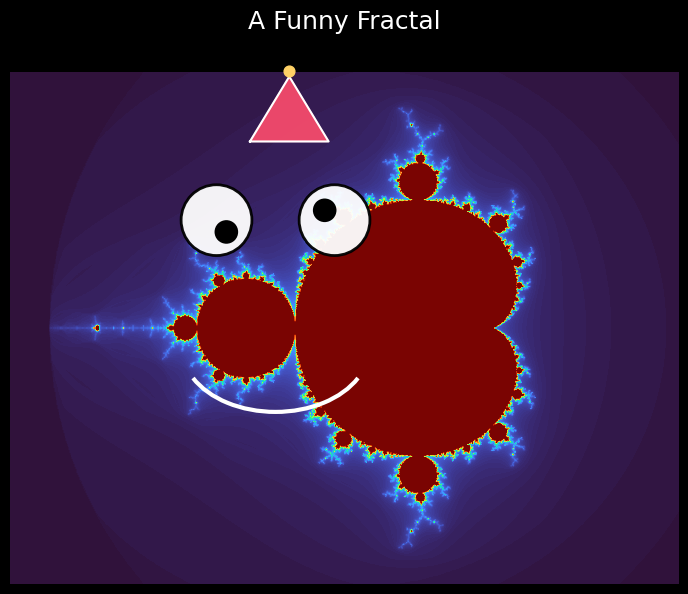

In [2]:
show me a funny fractal

In [11]:
stop_agent()

In [12]:
start_agent()

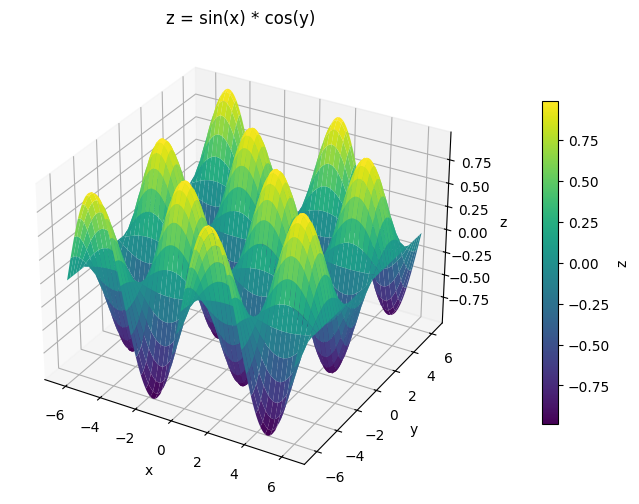

In [13]:
plot this: z = sin(x) * cos(y)

In [14]:
make a function for adding a plane z = a given value with a given color

Created function: add_constant_z_plane


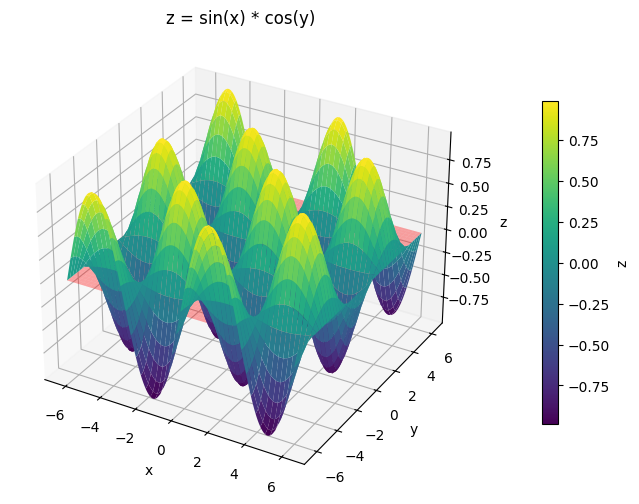

In [15]:
add the plane z=0 color red

In [16]:
pause_agent()

With the agent paused, let's manually call the generated function to add a new blue plan.

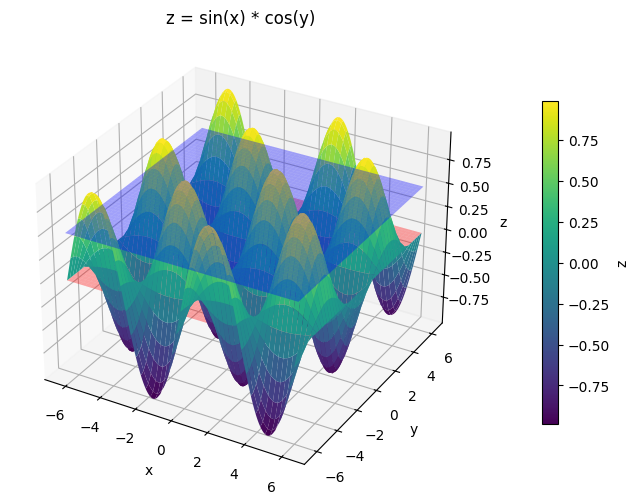

In [17]:
plane = add_constant_z_plane(ax, z_value=0.5, color="blue", X_grid=X, Y_grid=Y)
display(ax.figure)


In [18]:
resume_agent()

In [19]:
how many planes are in the plot?

In [7]:
stop_agent()

In [2]:
start_agent()

In [3]:
I have this: tips.csv 

Loaded tips.csv with shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


,dtype,missing
total_bill,float64,0
tip,float64,0
sex,object,0
smoker,object,0
day,object,0
time,object,0
size,int64,0


numeric_cols: ['total_bill', 'tip', 'size']
categorical_cols: ['sex', 'smoker', 'day', 'time']


Quick EDA for tips_df


,value
rows,244
columns,8
duplicate_rows,1


,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.94
1,10.34,1.66,Male,No,Sun,Dinner,3,16.05
2,21.01,3.50,Male,No,Sun,Dinner,3,16.66
3,23.68,3.31,Male,No,Sun,Dinner,2,13.98
4,24.59,3.61,Female,No,Sun,Dinner,4,14.68


,dtype
total_bill,float64
tip,float64
sex,object
smoker,object
day,object
time,object
size,int64


,missing_count
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


...

,day,count
0,Sat,87
1,Sun,76
2,Thur,62
3,Fri,19


Value counts for time


,time,count
0,Dinner,176
1,Lunch,68


Grouped summary by day and time


,day,time,party_count,avg_total_bill,avg_tip,avg_party_size,avg_tip_pct
0,Fri,Dinner,12,19.66,2.94,2.17,15.89
1,Fri,Lunch,7,12.85,2.38,2.00,18.88
2,Sat,Dinner,87,20.44,2.99,2.52,15.31
3,Sun,Dinner,76,21.41,3.26,2.84,16.69
4,Thur,Dinner,1,18.78,3.00,2.00,15.97
5,Thur,Lunch,61,17.66,2.77,2.46,16.13


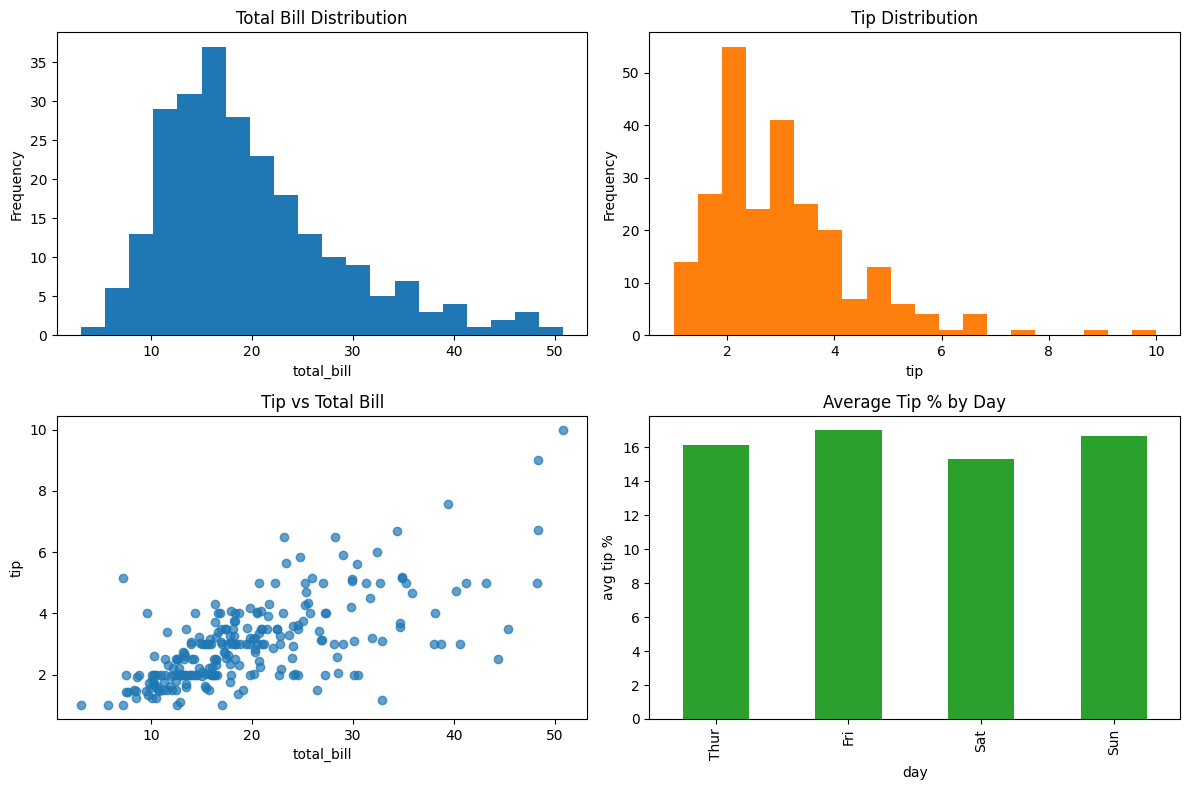

Created reusable symbols: tips_analysis_df, tips_shape_summary, tips_numeric_summary_df, tips_correlation_df, tips_group_summary_df, tips_categorical_counts


In [4]:
make a quick EDA on this tips

In [3]:
stop_agent()

In [4]:
start_agent()

In [2]:
Fa un graf cu orașe și rute, si apoi afiseaza cele mai scurte rute dintr-un oraș

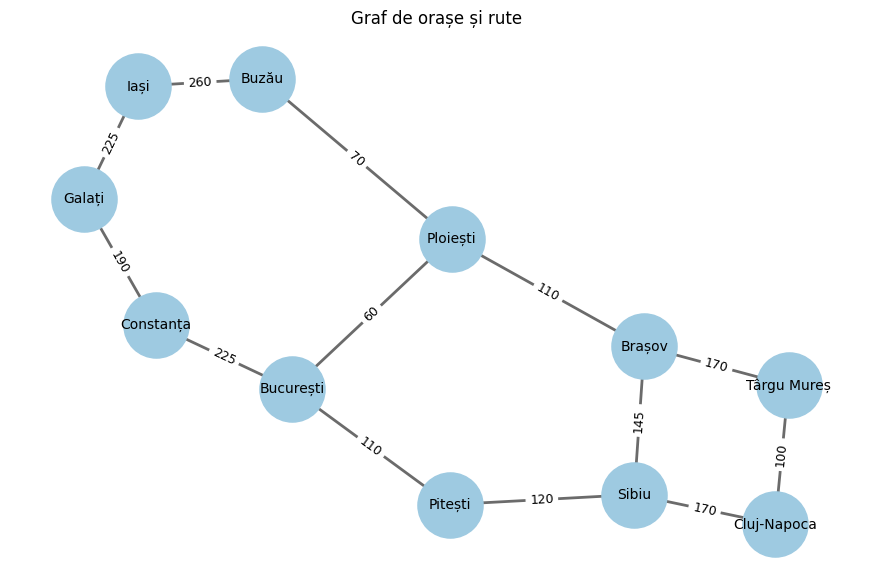

Cele mai scurte rute din București:


,destination,distance_km,path
0,București,0,București
1,Ploiești,60,București -> Ploiești
2,Pitești,110,București -> Pitești
3,Buzău,130,București -> Ploiești -> Buzău
4,Brașov,170,București -> Ploiești -> Brașov
5,Constanța,225,București -> Constanța
6,Sibiu,230,București -> Pitești -> Sibiu
7,Târgu Mureș,340,București -> Ploiești -> Brașov -> Târgu Mureș
8,Iași,390,București -> Ploiești -> Buzău -> Iași
9,Cluj-Napoca,400,București -> Pitești -> Sibiu -> Cluj-Napoca


Simboluri create: routes_df, city_graph, source_city, shortest_routes_df


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import networkx as nx
except ImportError as exc:
    raise ImportError("Pachetul 'networkx' nu este instalat. Instalează-l cu: pip install networkx") from exc


routes_data = [
    ("București", "Ploiești", 60),
    ("București", "Pitești", 110),
    ("București", "Constanța", 225),
    ("Ploiești", "Brașov", 110),
    ("Ploiești", "Buzău", 70),
    ("Brașov", "Sibiu", 145),
    ("Brașov", "Târgu Mureș", 170),
    ("Pitești", "Sibiu", 120),
    ("Sibiu", "Cluj-Napoca", 170),
    ("Târgu Mureș", "Cluj-Napoca", 100),
    ("Buzău", "Iași", 260),
    ("Constanța", "Galați", 190),
    ("Galați", "Iași", 225),
]

routes_df = pd.DataFrame(routes_data, columns=["source", "target", "distance_km"])


def build_city_graph(routes_df: pd.DataFrame) -> nx.Graph:
    """Construiește un graf neorientat, ponderat, dintr-un tabel de rute."""
    graph = nx.Graph()
    for row in routes_df.itertuples(index=False):
        graph.add_edge(row.source, row.target, weight=row.distance_km)
    return graph



def shortest_routes_from_city(graph: nx.Graph, source: str) -> pd.DataFrame:
    """Returnează cele mai scurte rute și distanțe din orașul sursă către toate celelalte orașe."""
    lengths = nx.single_source_dijkstra_path_length(graph, source, weight="weight")
    paths = nx.single_source_dijkstra_path(graph, source, weight="weight")

    shortest_routes_df = pd.DataFrame(
        {
            "destination": list(lengths.keys()),
            "distance_km": list(lengths.values()),
            "path": [" -> ".join(paths[city]) for city in lengths.keys()],
        }
    )
    shortest_routes_df = shortest_routes_df.sort_values(["distance_km", "destination"]).reset_index(drop=True)
    return shortest_routes_df


city_graph = build_city_graph(routes_df)
source_city = "București"

if source_city not in city_graph:
    raise ValueError(f"Orașul sursă '{source_city}' nu există în graf.")

pos = nx.spring_layout(city_graph, seed=42, k=1.2)
edge_labels = nx.get_edge_attributes(city_graph, "weight")

fig, ax = plt.subplots(figsize=(11, 7))
nx.draw_networkx(
    city_graph,
    pos=pos,
    ax=ax,
    with_labels=True,
    node_color="#9ecae1",
    node_size=2200,
    font_size=10,
    edge_color="#6b6b6b",
    width=2,
)
nx.draw_networkx_edge_labels(
    city_graph,
    pos=pos,
    edge_labels=edge_labels,
    font_size=9,
    ax=ax,
)
ax.set_title("Graf de orașe și rute")
ax.axis("off")
display(fig)
plt.close(fig)

shortest_routes_df = shortest_routes_from_city(city_graph, source_city)
print(f"Cele mai scurte rute din {source_city}:")
display(shortest_routes_df)
print("Simboluri create: routes_df, city_graph, source_city, shortest_routes_df")
